<a href="https://colab.research.google.com/github/MRizetteSayo/CPE-018-CPE32S1/blob/main/Face%20Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = "/content/drive/MyDrive/Colab Notebooks/dataset"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


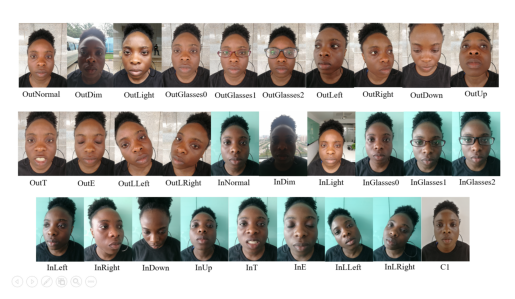

In [29]:
import cv2
import matplotlib.pyplot as plt

image_path = "/content/drive/MyDrive/Colab Notebooks/dataset/person_1/1.png"

img = cv2.imread(image_path)

# Convert BGR to RGB (important for correct colors)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [30]:
import os

dataset_path = "/content/drive/MyDrive/Colab Notebooks/dataset"

print("Inside dataset:", os.listdir(dataset_path))

Inside dataset: ['person_1', 'person_2']


In [31]:
import numpy as np
import os
import cv2

def read_images(path, sz=None):
    X, y = [], []

    if not os.path.exists(path):
        print("Dataset path does NOT exist!")
        return X, y

    label = 0

    # Only loop through first-level folders
    for folder_name in sorted(os.listdir(path)):
        folder_path = os.path.join(path, folder_name)

        if not os.path.isdir(folder_path):
            continue

        print("Reading folder:", folder_name)

        for filename in os.listdir(folder_path):

            if filename.startswith("."):
                continue

            filepath = os.path.join(folder_path, filename)

            im = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

            if im is None:
                print("Could not read:", filepath)
                continue

            if sz is not None:
                im = cv2.resize(im, sz)

            X.append(im)
            y.append(label)

        label += 1

    return X, y

In [32]:
import os
for root, dirs, files in os.walk(dataset_path):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", files)
    print("------")

ROOT: /content/drive/MyDrive/Colab Notebooks/dataset
DIRS: ['person_1', 'person_2']
FILES: []
------
ROOT: /content/drive/MyDrive/Colab Notebooks/dataset/person_1
DIRS: []
FILES: ['1.png']
------
ROOT: /content/drive/MyDrive/Colab Notebooks/dataset/person_2
DIRS: []
FILES: ['2.png']
------


In [33]:
import numpy as np
import cv2
import os
from google.colab.patches import cv2_imshow

def face_rec(dataset_path):

    names = ['Friend1', 'Friend2']  #inside data set

    # Load training data
    X, y = read_images(dataset_path, sz=(200,200))
    y = np.asarray(y, dtype=np.int32)

    # Train model
    model = cv2.face.EigenFaceRecognizer_create()
    model.train(X, y)

    # Load Haar cascade from OpenCV
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )

    # Use image instead of webcam (upload test image)
    test_image_path = "/content/drive/MyDrive/Colab Notebooks/orange.png"
    img = cv2.imread(test_image_path)

    if img is None:
        print("Test image not found!")
        return

    gray_full = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_full, 1.3, 5)

    for (x, y_pos, w, h) in faces:
        face = gray_full[y_pos:y_pos+h, x:x+w]
        roi = cv2.resize(face, (200, 200))

        label, confidence = model.predict(roi)

        cv2.rectangle(img, (x, y_pos), (x+w, y_pos+h), (255,0,0), 2)
        cv2.putText(img,
                    names[label] + " " + str(round(confidence,2)),
                    (x, y_pos-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (255,0,0),
                    2)

    cv2_imshow(img)

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Image loaded!


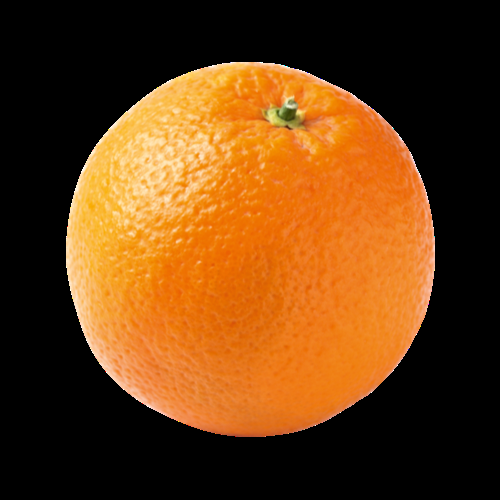

In [34]:
from google.colab.patches import cv2_imshow
import cv2

test_image_path = "/content/drive/MyDrive/Colab Notebooks/orange.png"

img = cv2.imread(test_image_path)

if img is None:
    print("Image not found!")
else:
    print("Image loaded!")
    cv2_imshow(img)

In [35]:
print("Faces detected:", len(faces))

Faces detected: 0


Faces detected: 0


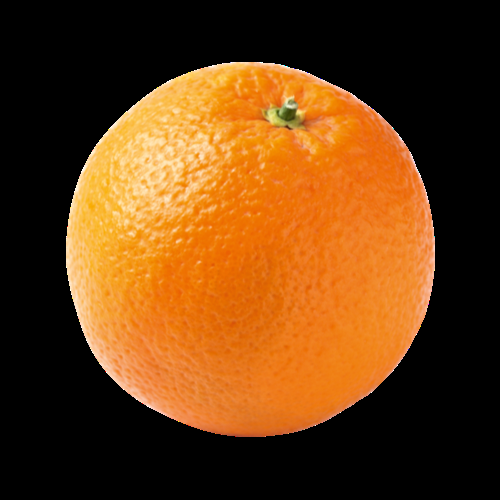

In [36]:
from google.colab.patches import cv2_imshow
import cv2

image_path = "/content/drive/MyDrive/Colab Notebooks/orange.png"

img = cv2.imread(image_path)

if img is None:
    print("Image not found!")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    print("Faces detected:", len(faces))

    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    cv2_imshow(img)